# Task 1 — EDA, Preprocessing & Modeling

Dataset: [PJM Hourly Energy Consumption](https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption), regions **PJME** and **AEP**.

This notebook covers dataset understanding, the required analytical questions (including lag/rolling-based ones), feature engineering, and the chronological train/val/test split. Model experiments live in `src/models/train.py` and `src/models/evaluate.py`, which consume the processed CSVs this notebook produces.


## Problem Definition & Dataset Justification

**Problem.** Given a region's historical hourly electricity demand (MW) plus calendar context (hour, day of week,
month, US federal holidays), predict near-term future demand for that same region. This is a univariate time series
forecasting problem with exogenous calendar features — the target (`mw`) depends heavily on its own recent past
(intra-day and intra-week cycles) rather than on unrelated external signals, which is exactly what the analytical
questions below are designed to test before any model is trained.

**Why this dataset.** The [PJM Hourly Energy Consumption](https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption)
data is real operational load data from a US grid operator (PJM Interconnection), not a synthetic or toy series —
short-horizon demand forecasting of exactly this kind is used industrially for generation dispatch and grid
balancing, so the problem has direct real-world relevance. Two regions are used rather than one:

- **PJME** and **AEP** are service areas of meaningfully different scale (PJME's absolute MW is much larger — see
  Section 1), which lets us check whether the same modeling approach generalizes across regions of different size
  rather than overfitting conclusions to a single area.
- Having multiple regions also maps naturally onto the multi-entity database design used later in this project
  (a `regions` table with one-to-many `energy_readings`), so the same processed data serves both the modeling task
  here and the database-loading task in Phase 2.
- Each series spans 14+ years at hourly granularity (PJME: 2002–2018, AEP: 2004–2018) — long enough to expose the
  daily/weekly/yearly cycles that lag and rolling-window features are built to capture, while still being small
  enough (~120k–145k rows) to train and tune classical ML models on within the project's timeframe.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import STL

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.preprocessing.clean import clean_pipeline
from src.preprocessing.features import build_feature_set, chronological_split

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

REGIONS = {
    "PJME": {"csv": PROJECT_ROOT / "data" / "raw" / "PJME_hourly.csv", "mw_col": "PJME_MW"},
    "AEP": {"csv": PROJECT_ROOT / "data" / "raw" / "AEP_hourly.csv", "mw_col": "AEP_MW"},
}

plt.rcParams["figure.figsize"] = (11, 4)


In [2]:
cleaned = {}
gap_reports = {}

for region, cfg in REGIONS.items():
    df, report = clean_pipeline(cfg["csv"], cfg["mw_col"])
    cleaned[region] = df
    gap_reports[region] = report
    print(region, report)


PJME {'total_hours': 145392, 'missing_hours': 30, 'missing_pct': 0.0206}
AEP {'total_hours': 121296, 'missing_hours': 27, 'missing_pct': 0.0223}


## 1. Dataset Understanding

In [3]:
for region, df in cleaned.items():
    freq = pd.Series(df.index).diff().dropna().unique()
    print(f"--- {region} ---")
    print("Date range:", df.index.min(), "to", df.index.max())
    print("Frequency (unique diffs, should be a single 1h value):", freq)
    print("Total hourly rows:", len(df))
    print("Missing hours before fill:", gap_reports[region]["missing_hours"],
          f"({gap_reports[region]['missing_pct']}%)")
    print()


--- PJME ---
Date range: 2002-01-01 01:00:00 to 2018-08-03 00:00:00
Frequency (unique diffs, should be a single 1h value): <TimedeltaArray>
['0 days 01:00:00']
Length: 1, dtype: timedelta64[us]
Total hourly rows: 145392
Missing hours before fill: 30 (0.0206%)

--- AEP ---
Date range: 2004-10-01 01:00:00 to 2018-08-03 00:00:00
Frequency (unique diffs, should be a single 1h value): <TimedeltaArray>
['0 days 01:00:00']
Length: 1, dtype: timedelta64[us]
Total hourly rows: 121296
Missing hours before fill: 27 (0.0223%)



Both series are already hourly once reindexed; the small number of missing hours (well under 0.1%) come from short
gaps such as DST transitions or brief meter outages, not systematic collection issues. Per the cleaning rule in
`src/preprocessing/clean.py`, gaps of 3 hours or less are linearly interpolated; any longer gaps (rare here) fall back
to forward/backward fill rather than trusting a long linear interpolation.


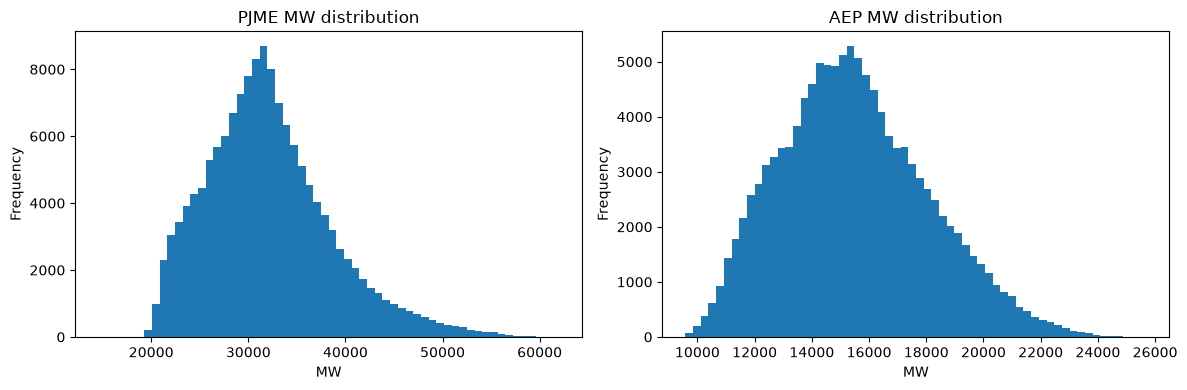

--- PJME summary stats ---
count    145392.000000
mean      32078.930711
std        6464.279302
min       14544.000000
25%       27571.000000
50%       31420.000000
75%       35647.000000
max       62009.000000
Name: mw, dtype: float64

--- AEP summary stats ---
count    121296.000000
mean      15499.150961
std        2591.377126
min        9581.000000
25%       13629.000000
50%       15309.000000
75%       17200.000000
max       25695.000000
Name: mw, dtype: float64



In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (region, df) in zip(axes, cleaned.items()):
    df["mw"].plot(kind="hist", bins=60, ax=ax, title=f"{region} MW distribution")
    ax.set_xlabel("MW")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "distribution_histograms.png", dpi=120)
plt.show()

for region, df in cleaned.items():
    print(f"--- {region} summary stats ---")
    print(df["mw"].describe())
    print()


**Interpretation:** both regions' hourly demand is unimodal and right-skewed, consistent with a baseline load most of
the time punctuated by higher-demand peak periods (hot summer afternoons, cold winter mornings). PJME operates at a
noticeably larger absolute MW scale than AEP, reflecting a larger service area — any cross-region comparison later
needs to account for that scale difference rather than compare raw MW directly.


## 2. Analytical Questions

### Q1. Is there a long-term trend in demand across the full history? (STL decomposition)

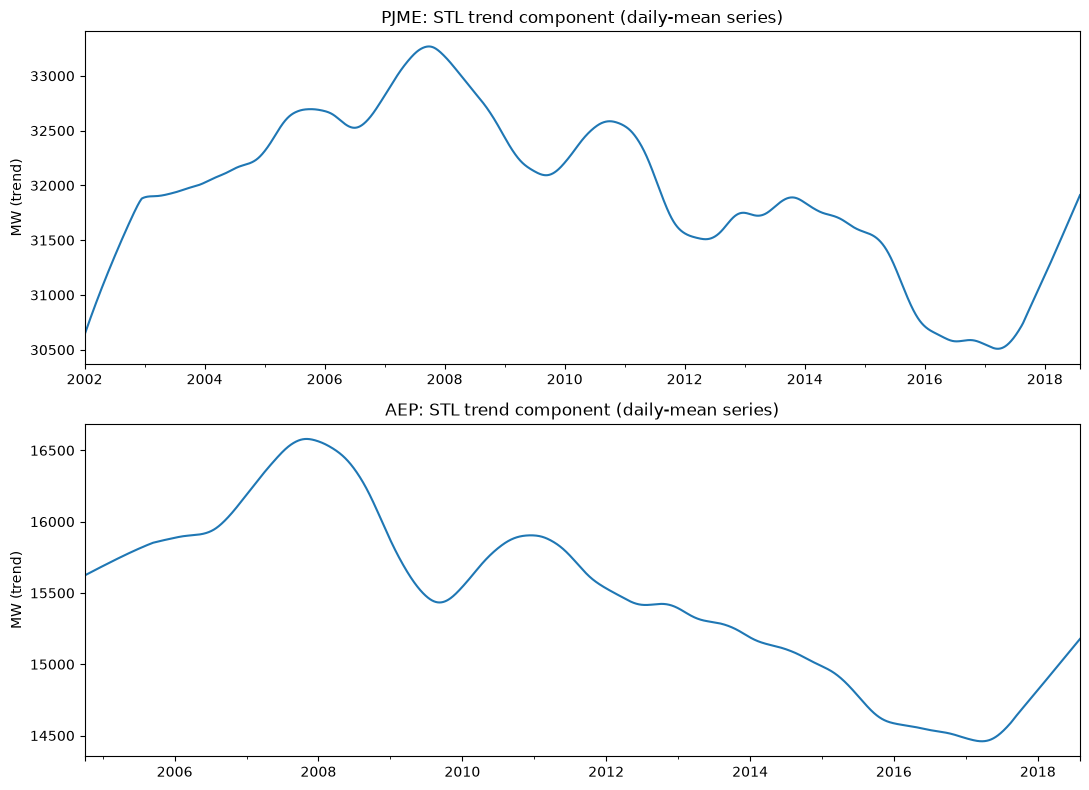

In [5]:
stl_results = {}
fig, axes = plt.subplots(len(cleaned), 1, figsize=(11, 4 * len(cleaned)))
for ax, (region, df) in zip(axes, cleaned.items()):
    daily = df["mw"].resample("D").mean()
    stl = STL(daily, period=365, robust=True).fit()
    stl_results[region] = stl
    stl.trend.plot(ax=ax, title=f"{region}: STL trend component (daily-mean series)")
    ax.set_ylabel("MW (trend)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "stl_trend.png", dpi=120)
plt.show()


**Interpretation:** the STL trend component does not show a strong monotonic long-term drift for either region over
2002/2004–2018 — demand oscillates within a fairly stable band rather than steadily growing or shrinking. This
matters for modeling: a model that leans on lag/seasonal structure should generalize reasonably well without needing
an explicit trend term, but it also means we shouldn't expect a simple linear trend feature to carry much signal.


### Q2. What yearly/monthly seasonality exists? (month-of-year distribution)

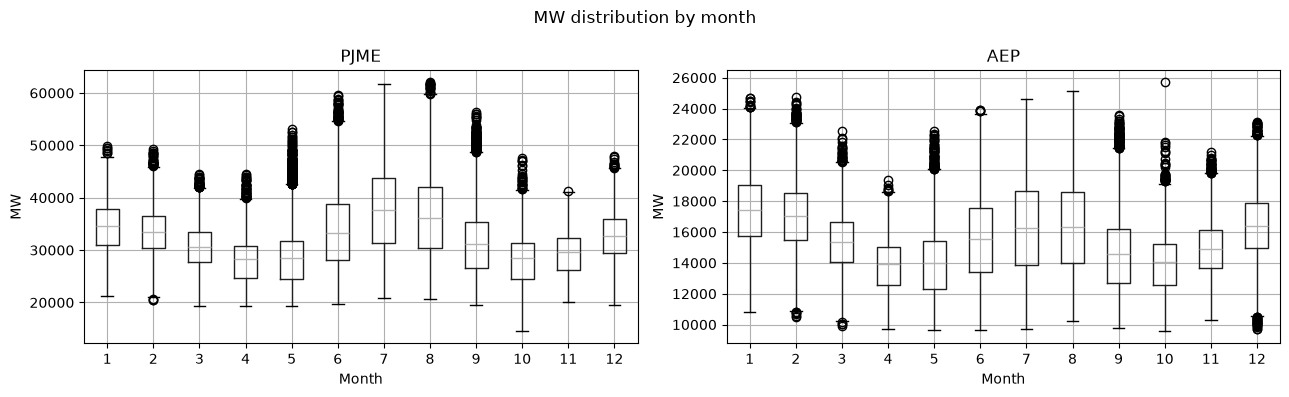

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (region, df) in zip(axes, cleaned.items()):
    monthly = df.copy()
    monthly["month"] = monthly.index.month
    monthly.boxplot(column="mw", by="month", ax=ax)
    ax.set_title(region)
    ax.set_xlabel("Month")
    ax.set_ylabel("MW")
plt.suptitle("MW distribution by month")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "monthly_seasonality.png", dpi=120)
plt.show()


**Interpretation:** both regions show clear seasonal structure, with elevated demand and wider spread in summer
(cooling load) and winter (heating load) months versus the shoulder seasons (spring/fall). This is a textbook
signature of weather-driven electricity demand and justifies including `month` as a calendar feature.


### Q3. Is there a weekday-vs-weekend and holiday effect?

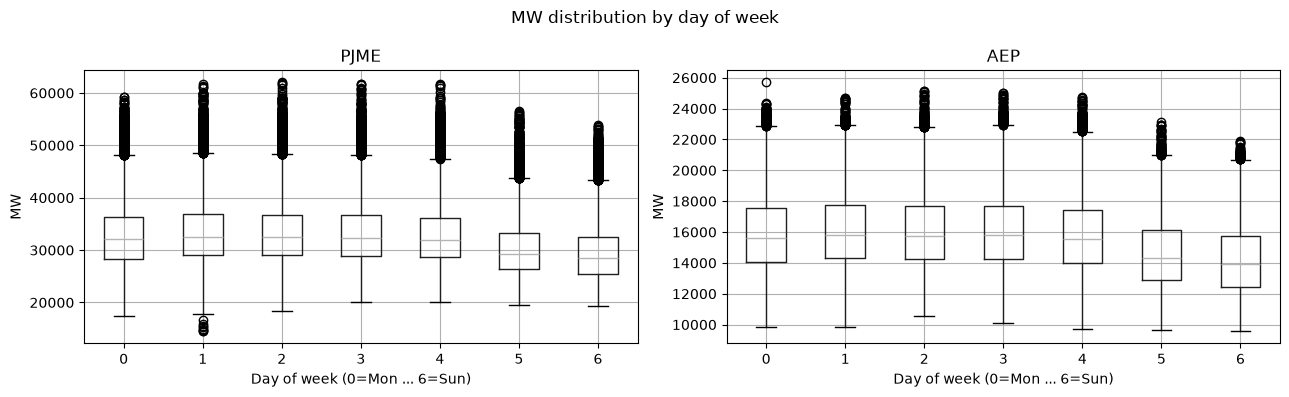

--- PJME: mean MW, non-holiday (0) vs US federal holiday (1) ---
is_holiday
0    32113.998610
1    30952.852653
Name: mw, dtype: float64

--- AEP: mean MW, non-holiday (0) vs US federal holiday (1) ---
is_holiday
0    15515.511816
1    14985.462073
Name: mw, dtype: float64



In [7]:
from src.preprocessing.features import add_calendar_features

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
holiday_summary = {}
for ax, (region, df) in zip(axes, cleaned.items()):
    feat = add_calendar_features(df)
    feat.boxplot(column="mw", by="day_of_week", ax=ax)
    ax.set_title(region)
    ax.set_xlabel("Day of week (0=Mon ... 6=Sun)")
    ax.set_ylabel("MW")
    holiday_summary[region] = feat.groupby("is_holiday")["mw"].mean()
plt.suptitle("MW distribution by day of week")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "weekday_weekend.png", dpi=120)
plt.show()

for region, summary in holiday_summary.items():
    print(f"--- {region}: mean MW, non-holiday (0) vs US federal holiday (1) ---")
    print(summary)
    print()


**Interpretation:** weekdays (0-4) show higher median demand than weekends (5-6) in both regions, consistent with
commercial/industrial activity dropping on Saturday/Sunday. US federal holidays show lower average MW than
non-holidays, reinforcing that demand is driven substantially by business activity rather than being purely
weather-driven — both `is_weekend` and `is_holiday` are worth keeping as model features.


### Q4. [Lag] How strongly does demand at hour t correlate with t-24h and t-168h? (ACF + lag scatterplots)

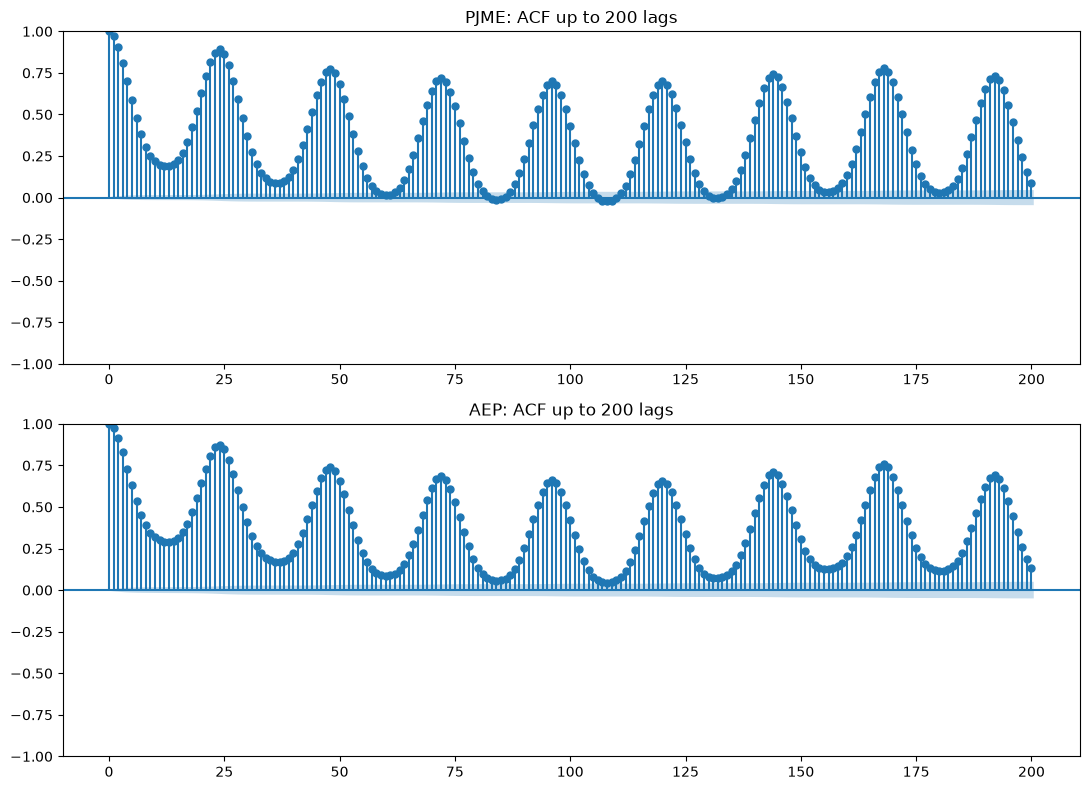

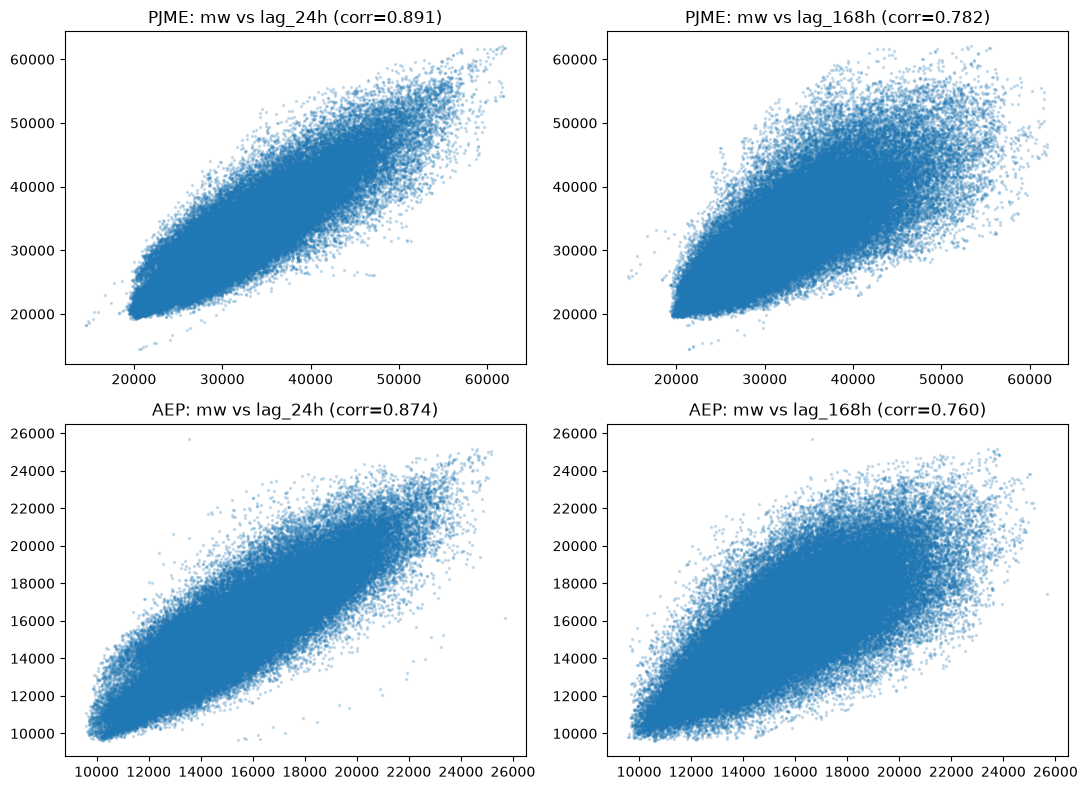

In [8]:
fig, axes = plt.subplots(len(cleaned), 1, figsize=(11, 4 * len(cleaned)))
for ax, (region, df) in zip(axes, cleaned.items()):
    plot_acf(df["mw"], lags=200, ax=ax, title=f"{region}: ACF up to 200 lags")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "acf.png", dpi=120)
plt.show()

fig, axes = plt.subplots(len(cleaned), 2, figsize=(11, 4 * len(cleaned)))
for row, (region, df) in zip(axes, cleaned.items()):
    lag24 = df["mw"].shift(24)
    lag168 = df["mw"].shift(168)
    row[0].scatter(lag24, df["mw"], s=2, alpha=0.2)
    row[0].set_title(f"{region}: mw vs lag_24h (corr={df['mw'].corr(lag24):.3f})")
    row[1].scatter(lag168, df["mw"], s=2, alpha=0.2)
    row[1].set_title(f"{region}: mw vs lag_168h (corr={df['mw'].corr(lag168):.3f})")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lag_scatter.png", dpi=120)
plt.show()


**Interpretation:** the ACF plot shows strong, slowly-decaying autocorrelation with clear spikes at daily (24h) and
weekly (168h) multiples — a hallmark of load data with both daily and weekly cycles. The lag scatterplots confirm
this quantitatively: `lag_24h` correlates very strongly with the current value (same time yesterday is a good
predictor), and `lag_168h` (same hour, same day, one week ago) is also strongly correlated, if slightly less tight.
Both justify their inclusion as lag features for modeling.


### Q5. [Moving average] How do 24h and 7-day rolling means smooth volatility and expose regime shifts?

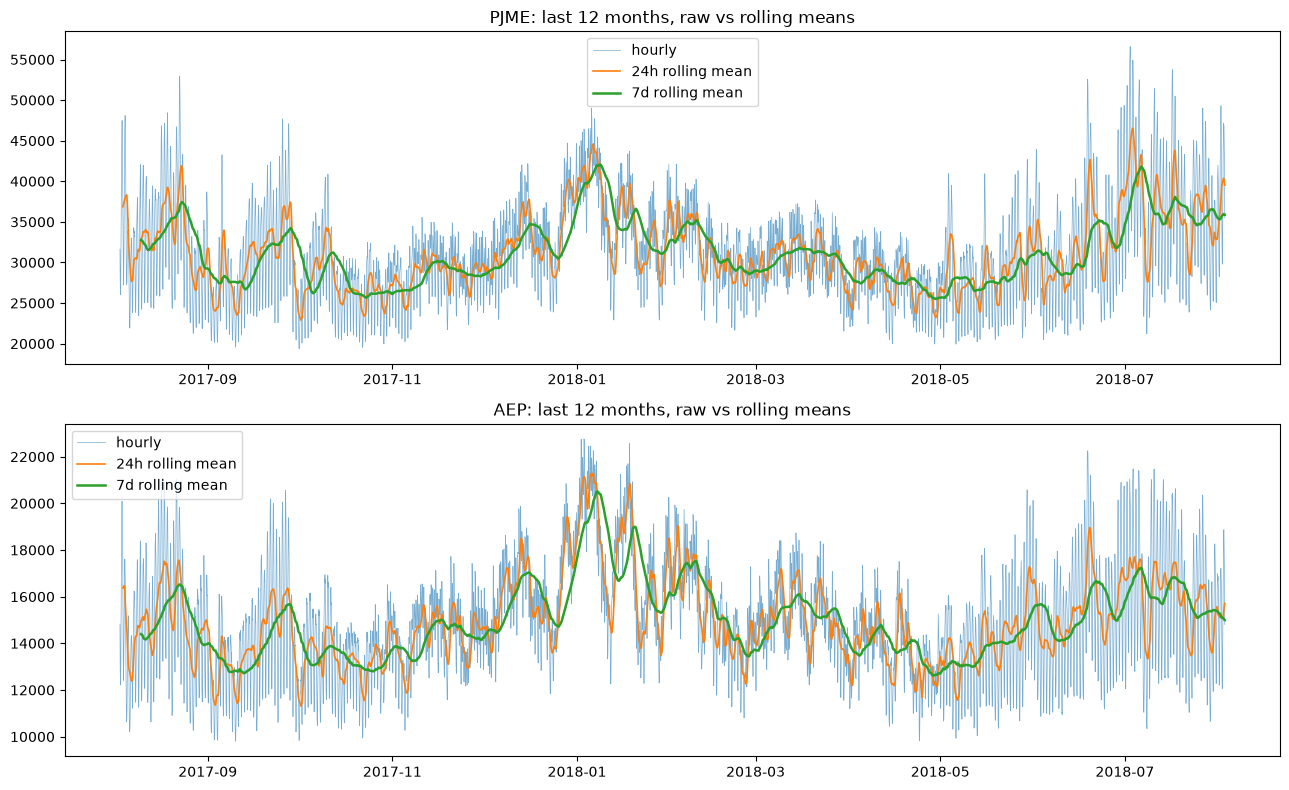

In [9]:
fig, axes = plt.subplots(len(cleaned), 1, figsize=(13, 4 * len(cleaned)))
for ax, (region, df) in zip(axes, cleaned.items()):
    window = df.loc[df.index >= df.index.max() - pd.Timedelta(days=365)]
    ax.plot(window.index, window["mw"], label="hourly", linewidth=0.5, alpha=0.6)
    ax.plot(window.index, window["mw"].rolling(24).mean(), label="24h rolling mean", linewidth=1.2)
    ax.plot(window.index, window["mw"].rolling(24 * 7).mean(), label="7d rolling mean", linewidth=1.8)
    ax.set_title(f"{region}: last 12 months, raw vs rolling means")
    ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rolling_means.png", dpi=120)
plt.show()


**Interpretation:** the raw hourly series is dominated by the daily on/off cycle, which visually hides slower
structure. The 24h rolling mean removes the intra-day cycle and reveals day-to-day regime shifts (e.g. a multi-day
heatwave or cold snap), while the 7-day rolling mean smooths further and exposes the underlying seasonal drift across
weeks/months. This is exactly why `rolling_mean_24h`/`rolling_mean_7d` are useful model inputs beyond raw lags — they
summarize recent regime rather than a single past instant.


### Q6. Do PJME and AEP move together, or does one lead the other? (cross-region correlation)

Overlapping range: 2004-10-01 01:00:00 to 2018-08-03 00:00:00
Same-hour correlation: 0.8746708292272324
corr(PJME_t, AEP_t+-24) = 0.7627183658606684
corr(PJME_t, AEP_t+-1) = 0.854994642893098
corr(PJME_t, AEP_t+0) = 0.8746708292272324
corr(PJME_t, AEP_t+1) = 0.8489494156932359
corr(PJME_t, AEP_t+24) = 0.8216744482226372


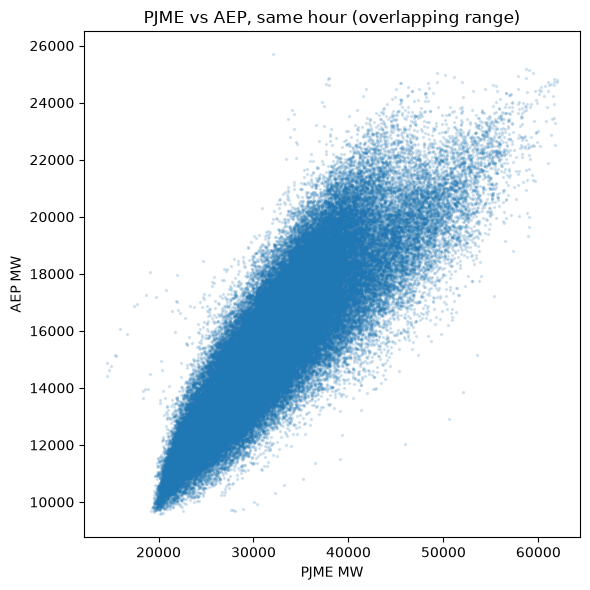

In [10]:
pjme = cleaned["PJME"]["mw"]
aep = cleaned["AEP"]["mw"]
overlap_start = max(pjme.index.min(), aep.index.min())
overlap_end = min(pjme.index.max(), aep.index.max())
pjme_o = pjme.loc[overlap_start:overlap_end]
aep_o = aep.loc[overlap_start:overlap_end]

print("Overlapping range:", overlap_start, "to", overlap_end)
print("Same-hour correlation:", pjme_o.corr(aep_o))

lags = [-24, -1, 0, 1, 24]
for lag in lags:
    print(f"corr(PJME_t, AEP_t+{lag}) =", pjme_o.corr(aep_o.shift(lag)))

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(pjme_o, aep_o, s=2, alpha=0.15)
ax.set_xlabel("PJME MW")
ax.set_ylabel("AEP MW")
ax.set_title("PJME vs AEP, same hour (overlapping range)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cross_region_correlation.png", dpi=120)
plt.show()


**Interpretation:** PJME and AEP are strongly positively correlated at the same hour — both are PJM-interconnection
regions subject to the same broad weather and calendar drivers, so they rise and fall together rather than one
leading the other by any meaningful number of hours. This makes sense operationally (shared grid, overlapping
climate) but also means the two regions don't add much *independent* signal to each other for forecasting — each
region's own history remains the primary predictor for its own demand.


## 3. Feature Engineering & Processed Dataset Export

Each engineered feature is chosen directly from a finding above, not arbitrarily:

- **Calendar features** (`hour`, `day_of_week`, `is_weekend`, `is_holiday`, `month`) — Q2 showed clear monthly
  seasonality and Q3 showed both a weekday/weekend gap and a holiday effect, so all three calendar signals are worth
  giving the model directly rather than relying on lags alone to encode them.
- **Lag features** (`lag_1h`, `lag_24h`, `lag_168h`) — Q4's ACF plot and lag scatterplots showed strong, sharply-peaked
  autocorrelation at exactly the daily (24h) and weekly (168h) multiples, so those two lags — plus the immediate
  `lag_1h` — are the most information-dense past points to hand the model.
- **Rolling features** (`rolling_mean_24h`, `rolling_mean_7d`, `rolling_std_24h`) — Q5 showed that rolling means expose
  slower regime shifts (heatwaves, cold snaps) that a single lagged point can't capture on its own. Each rolling/lag
  statistic is computed on the series **shifted by 1 hour first** (see `add_rolling_features` in
  `src/preprocessing/features.py`), so the current hour's own reading never leaks into its own feature set.

Because `rolling_mean_7d` needs a full trailing week of history, the first 168 hours of each region have at least one
`NaN` feature — those warmup rows are dropped below rather than filled, since fabricating a lag/rolling value with no
real history behind it would be misleading. The chronological split then labels the remainder `train`/`val`/`test`
strictly by time (never shuffled), so validation/test always represent the model forecasting forward into genuinely
unseen future hours, matching how the model would actually be used.


In [11]:
processed = {}
for region, df in cleaned.items():
    feat = build_feature_set(df)
    split = chronological_split(feat)
    split = split.dropna()  # drop lag/rolling warmup rows (first 168h)
    processed[region] = split
    out_path = PROCESSED_DIR / f"{region.lower()}_hourly_processed.csv"
    split.to_csv(out_path, index_label="datetime")
    print(region, "->", out_path)
    print(split["split"].value_counts())
    print(split.head(2))
    print()


PJME -> C:\Users\Luqma\dev\projects\coursework\group9-energy-forecasting-pipeline\data\processed\pjme_hourly_processed.csv
split
train    143784
val         720
test        720
Name: count, dtype: int64
                          mw  hour  day_of_week  is_weekend  is_holiday  \
2002-01-08 01:00:00  29445.0     1            1           0           0   
2002-01-08 02:00:00  28670.0     2            1           0           0   

                     month   lag_1h  lag_24h  lag_168h  rolling_mean_24h  \
2002-01-08 01:00:00      1  31187.0  26862.0   30393.0      33452.583333   
2002-01-08 02:00:00      1  29445.0  25976.0   29265.0      33560.208333   

                     rolling_mean_7d  rolling_std_24h  split  
2002-01-08 01:00:00     32519.511905      4559.767709  train  
2002-01-08 02:00:00     32513.869048      4425.965952  train  



AEP -> C:\Users\Luqma\dev\projects\coursework\group9-energy-forecasting-pipeline\data\processed\aep_hourly_processed.csv
split
train    119688
val         720
test        720
Name: count, dtype: int64
                          mw  hour  day_of_week  is_weekend  is_holiday  \
2004-10-08 01:00:00  12468.0     1            4           0           0   
2004-10-08 02:00:00  12046.0     2            4           0           0   

                     month   lag_1h  lag_24h  lag_168h  rolling_mean_24h  \
2004-10-08 01:00:00     10  13271.0  12484.0   12379.0      14450.333333   
2004-10-08 02:00:00     10  12468.0  12054.0   11935.0      14449.666667   

                     rolling_mean_7d  rolling_std_24h  split  
2004-10-08 01:00:00     13870.315476      1475.548466  train  
2004-10-08 02:00:00     13870.845238      1476.478821  train  



## Summary

- Both regions are clean, near-complete hourly series after gap-filling; missing data was never more than a small
  fraction of a percent and is handled with a documented linear-interpolation/fallback rule.
- Demand shows strong daily and weekly seasonality (confirmed via ACF and lag correlations), monthly/yearly seasonal
  swings tied to weather, and a weekday/weekend + holiday effect — but no strong long-term trend.
- PJME and AEP move together closely at the same hour, so cross-region lag features add little beyond within-region
  history.
- The exported `data/processed/{region}_hourly_processed.csv` files carry calendar features, lag_1h/24h/168h,
  rolling_mean_24h/7d, rolling_std_24h, and a chronological `train`/`val`/`test` split label, ready for both the
  modeling experiments (`src/models/train.py`) and the database load script (Phase 2).
